In [1]:
pip install "numpy<2.0,>=1.24.0"

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [3]:
pip install opencv-python matplotlib

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'D:\\Project\\Waste Classification\\WasteClassification\\imageclassification\\Lib\\site-packages\\~2mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Check the permissions.

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [4]:
!pip list

Package                      Version
---------------------------- -----------
absl-py                      2.3.1
asttokens                    3.0.0
astunparse                   1.6.3
blinker                      1.9.0
cachetools                   5.5.2
certifi                      2025.8.3
charset-normalizer           3.4.3
click                        8.2.1
colorama                     0.4.6
comm                         0.2.3
contourpy                    1.3.2
cycler                       0.12.1
debugpy                      1.8.16
decorator                    5.2.1
exceptiongroup               1.3.0
executing                    2.2.0
Flask                        3.1.2
flatbuffers                  25.2.10
fonttools                    4.60.1
gast                         0.4.0
google-auth                  2.40.3
google-auth-oauthlib         0.4.6
google-pasta                 0.2.0
grpcio                       1.74.0
h5py                         3.14.0
idna                         3.10
ip

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [5]:
import tensorflow as tf
import os

In [6]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [7]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [8]:
import tensorflow as tf

# Check available physical devices
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus)

# Quick test
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU Available (legacy check):", tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None))


GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available: 1
Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU Available (legacy check): True


In [9]:
from tensorflow.python.client import device_lib

# List all local devices
devices = device_lib.list_local_devices()
for d in devices:
    if d.device_type == 'GPU':
        print(d.physical_device_desc)


device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
import cv2
import imghdr

In [11]:
data_dir = 'data1' 

In [12]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [13]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

In [14]:
import numpy as np
from matplotlib import pyplot as plt

In [15]:
data = tf.keras.utils.image_dataset_from_directory('data1')

Found 15515 files belonging to 12 classes.


In [16]:
data

<BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [17]:
data_iterator = data.as_numpy_iterator()

In [18]:
batch = data_iterator.next()

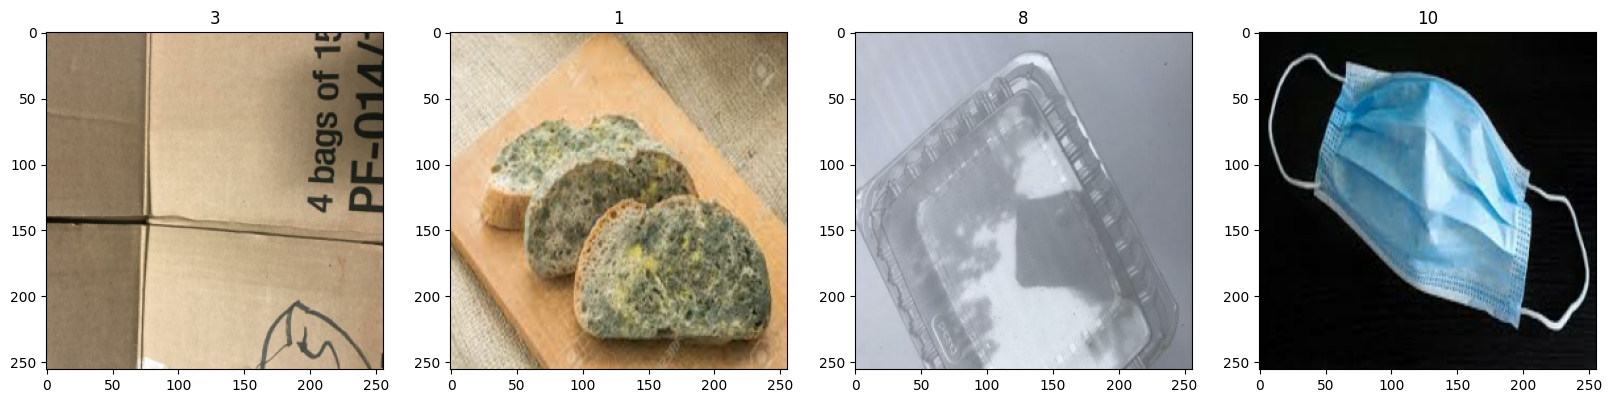

In [19]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [20]:
data = data.map(lambda x,y: (x/255, y))

In [21]:
scaled_iterator = data.as_numpy_iterator()

In [22]:
batch = scaled_iterator.next()

In [23]:
batch[0].min()

0.0

In [24]:
batch[0].max()

1.0

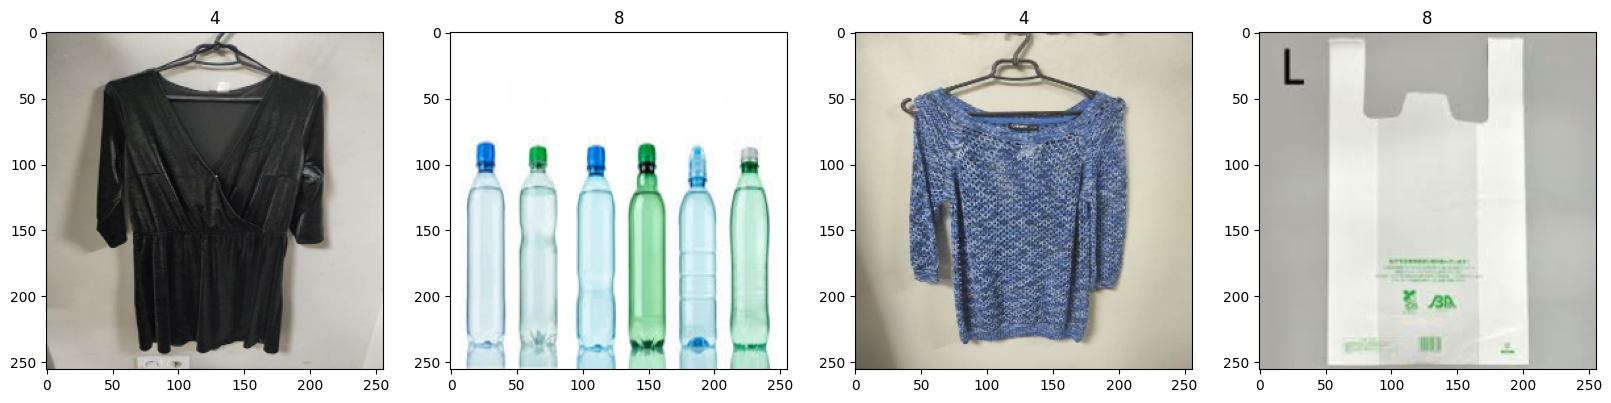

In [25]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [26]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [27]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

In [29]:
model = Sequential()

In [30]:
num_classes = 12

In [31]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Load VGG19 as base model (without top layers)
base_model = VGG19(include_top=False, input_shape=(256, 256, 3), weights="imagenet")
base_model.trainable = False  # freeze base model (use pretrained features)

# Build new model on top
model = Sequential([
    base_model,
    Flatten(),  # VGG uses Flatten
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # multi-class
])

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


80134624/80134624 [==============================] - 8s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 8, 8, 512)         20024384  
                                                                 
 flatten (Flatten)           (None, 32768)             0         
                                                                 
 dense (Dense)               (None, 512)               16777728  
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 12)                

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping and save best model
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model_VGG19.h5", save_best_only=True)
]

history = model.fit(
    train,  # your training dataset
    validation_data=val,  # your validation dataset
    epochs=50,
    callbacks=callbacks
)


Epoch 1/50


ResourceExhaustedError: Graph execution error:

Detected at node 'sequential_1/vgg19/block1_conv1/Relu' defined at (most recent call last):
    File "C:\Users\saras\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "C:\Users\saras\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "D:\Project\Waste Classification\WasteClassification\imageclassification\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "D:\Project\Waste Classification\WasteClassification\imageclassification\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "D:\Project\Waste Classification\WasteClassification\imageclassification\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "D:\Project\Waste Classific